# Medium Magnet B0 Mapping

In [1]:
import mrc
import pypulseq as pp
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def create_1d_se(te, t90, t180, ro_time = None, pw_time = None):
    system = pp.Opts(max_grad=32, grad_unit='mT/m', max_slew=130, rf_raster_time=1/120e6, block_duration_raster=1/120e6, grad_raster_time=1/120e6, slew_unit='mT/m/ms')
    seq = pp.Sequence(system=system)

    dead_time = 10e-6

    grad_strength = 10
    grad_rise_time = 10e-6

    system = pp.Opts(max_grad=32, grad_unit='mT/m', max_slew=130, rf_raster_time=1/120e6, block_duration_raster=1/120e6, grad_raster_time=1/120e6, slew_unit='mT/m/ms')
    seq = pp.Sequence(system=system)

    if(ro_time is None):
        ro_time = 2e-3
    if(pw_time is None):
        pw_time = ro_time/2

    g_readout_x = pp.make_trapezoid(channel="y", flat_area=grad_strength, flat_time=ro_time, system=system)
    g_prewind_x = pp.make_trapezoid(channel="y", flat_area=grad_strength/2, flat_time=pw_time, system=system)

    rf90 = pp.make_block_pulse(flip_angle=np.pi/2, duration=t90, system=system)
    rf180 = pp.make_block_pulse(flip_angle=np.pi, duration=t180, phase_offset = np.pi/2, system=system)

    seq.add_block(rf90)
    seq.add_block(pp.make_delay(dead_time))
    seq.add_block(g_prewind_x)
    seq.add_block(pp.make_delay(te/2-t180/2 - pp.calc_duration(g_prewind_x) - dead_time))
    seq.add_block(rf180)
    seq.add_block(pp.make_delay((te-t180-pp.calc_duration(g_readout_x))/2))
    seq.add_block(g_readout_x)
    seq.add_block(pp.make_delay((te-t180-pp.calc_duration(g_readout_x))/2))

    return seq

In [55]:
te = 8e-3
t90 = 100e-6
t180 = 150e-6

seq = create_1d_se(te, t90, t180)
mrc.compile_sequence(seq, 'fieldmap8.mrc')

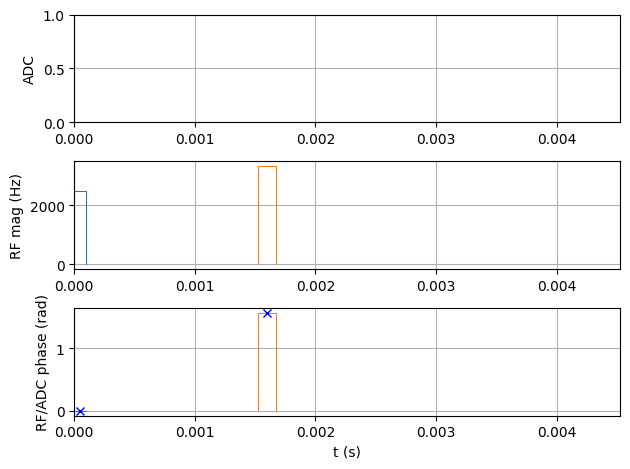

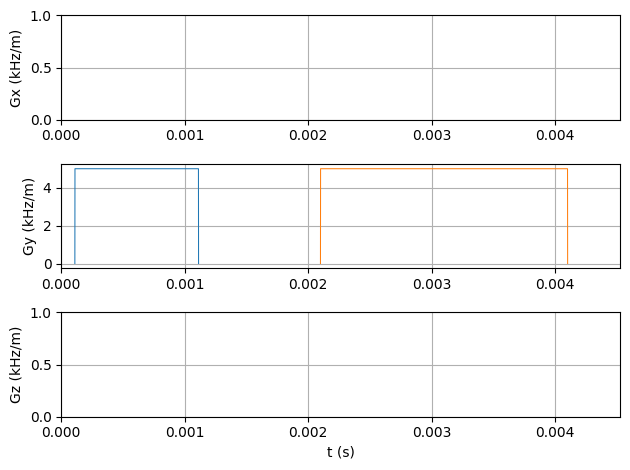

In [32]:
seq.plot()

In [33]:
mrr = mrc.Console(frequency=8.05e6)

Connected to COM3


Setting Coil Strength to 8 Counts/Hz
Setting Frequency to 8076500.0
Loading Sequence... Done.
Running Sequence
Received Bytes: 4800



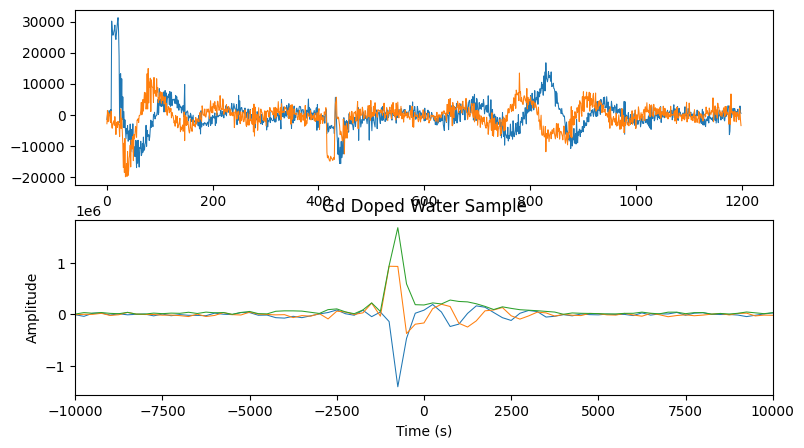

In [48]:
mrr.amp(8)
# mrr.attenuation(3)
# mrr.freq(8.06e6)
mrr.freq(8.0765e6) # probe reading is 1866. Grounding magnet to probe is very good for noise
mrr.run(mrc.build_spinecho(8e-3, 150e-6, 150e-6))
cpmg_fig, ax = plt.subplots(2,1,figsize=(9,5))
ax[0].plot(np.real(mrr.rx_data))
ax[0].plot(np.imag(mrr.rx_data))

ft = np.fft.fft(np.fft.fftshift(mrr.rx_data[700:1100]))
fs = np.fft.fftfreq(len(ft), d=1/100e3)
ax[1].plot(np.fft.fftshift(fs), np.real(np.fft.fftshift(ft)))
ax[1].plot(np.fft.fftshift(fs), np.imag(np.fft.fftshift(ft)))
ax[1].plot(np.fft.fftshift(fs), np.abs(np.fft.fftshift(ft)))
ax[1].set_xlim([-10000,10000])
plt.title("Gd Doped Water Sample")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
# plt.legend(["$T_2$ = %0.2f" % (mrc.get_t2(echo_amplitudes, 3e-3))]) # Put the calculated T2 in the legend
plt.show()  

Setting Coil Strength to 6 Counts/Hz
Setting Frequency to 8076500.0
Loading Sequence... Done.
Running Sequence
Received Bytes: 4800



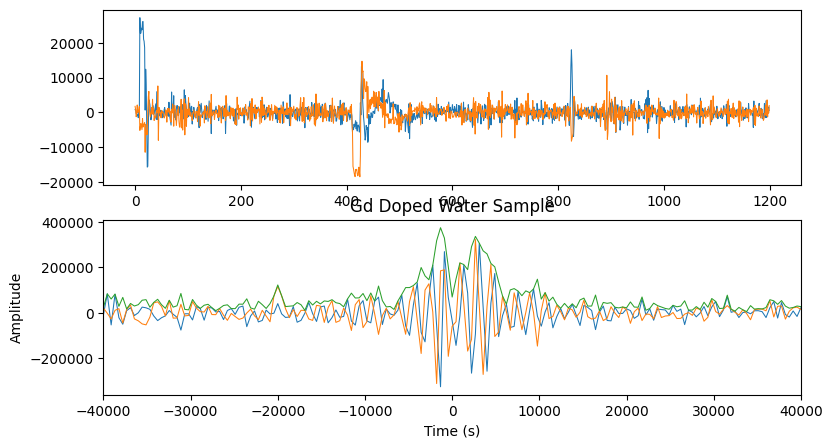

In [56]:
mrr.amp(6)
mrr.freq(8.0765e6)
mrr.run('fieldmap8.mrc')

cpmg_fig, ax = plt.subplots(2,1,figsize=(9,5))
ax[0].plot(np.real(mrr.rx_data))
ax[0].plot(np.imag(mrr.rx_data))

ft = np.fft.fft(np.fft.fftshift(mrr.rx_data[250:475]))
# ft = np.fft.fft(np.fft.fftshift(mrr.rx_data[450:600]))
fs = np.fft.fftfreq(len(ft), d=1/100e3)
ax[1].plot(np.fft.fftshift(fs), np.real(np.fft.fftshift(ft)))
ax[1].plot(np.fft.fftshift(fs), np.imag(np.fft.fftshift(ft)))
ax[1].plot(np.fft.fftshift(fs), np.abs(np.fft.fftshift(ft)))
ax[1].set_xlim([-40000,40000])
plt.title("Gd Doped Water Sample")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
# plt.legend(["$T_2$ = %0.2f" % (mrc.get_t2(echo_amplitudes, 3e-3))]) # Put the calculated T2 in the legend
plt.show()  

In [57]:
np.save("fm8.npy", mrr.rx_data)

In [51]:
mrr.run(mrc.build_cpmg(6e-3, 100, 500e-6, 150e-6))

Loading Sequence... Done.
Running Sequence
Received Bytes: 241344



In [35]:
mrc.mrcdump('fieldmap.mrc')

Duration: 464
Statics:
Phase 0: 0
Phase 1: 16384
Phase 2: 0
Phase 3: 0

Amp 0: 0
Amp 1: 1250
Amp 2: 2500
Amp 3: 0

Instructions:
0:	0001000000000000	cmd 	1 0 00 00 00
1:	0101000000000100	lset	1 4
2:	0100111111111101	lset	0 4093
3:	1000000000000011	jmp 	0 3
4:	1001000000000010	jmp 	1 2
5:	0100110110111100	lset	0 3516
6:	1000000000000110	jmp 	0 6
7:	0000000000000000	cmd 	0 0 00 00 00
8:	0100010010101101	lset	0 1197
9:	1000000000001001	jmp 	0 9
10:	0000000100000000	cmd 	0 0 01 00 00
11:	0101000000011100	lset	1 28
12:	0100111111111101	lset	0 4093
13:	1000000000001101	jmp 	0 13
14:	1001000000001100	jmp 	1 12
15:	0100010010111100	lset	0 1212
16:	1000000000010000	jmp 	0 16
17:	0000000000000000	cmd 	0 0 00 00 00
18:	0101000000001010	lset	1 10
19:	0100111111111101	lset	0 4093
20:	1000000000010100	jmp 	0 20
21:	1001000000010011	jmp 	1 19
22:	0100011011001100	lset	0 1740
23:	1000000000010111	jmp 	0 23
24:	0010010000000000	cmd 	2 1 00 00 00
25:	0101000000000100	lset	1 4
26:	0100111111111101	lset	0

In [ ]:
def create_1d_se(te, t90, t180, ro_time = None, pw_time = None):
    system = pp.Opts(max_grad=32, grad_unit='mT/m', max_slew=130, rf_raster_time=1/120e6, block_duration_raster=1/120e6, grad_raster_time=1/120e6, slew_unit='mT/m/ms')
    seq = pp.Sequence(system=system)

    dead_time = 10e-6

    grad_strength = 10
    grad_rise_time = 10e-6

    system = pp.Opts(max_grad=32, grad_unit='mT/m', max_slew=130, rf_raster_time=1/120e6, block_duration_raster=1/120e6, grad_raster_time=1/120e6, slew_unit='mT/m/ms')
    seq = pp.Sequence(system=system)

    if(ro_time is None):
        ro_time = 2e-3
    if(pw_time is None):
        pw_time = ro_time/2

    g_px = pp.make_trapezoid(channel="x", flat_area=grad_strength, flat_time=ro_time, system=system)
    g_nx = pp.make_trapezoid(channel="x", flat_area=-grad_strength, flat_time=ro_time, system=system)
    g_py = pp.make_trapezoid(channel="y", flat_area=grad_strength, flat_time=ro_time, system=system)
    g_ny = pp.make_trapezoid(channel="y", flat_area=-grad_strength, flat_time=ro_time, system=system)
    g_pz = pp.make_trapezoid(channel="z", flat_area=grad_strength, flat_time=ro_time, system=system)
    g_nz = pp.make_trapezoid(channel="z", flat_area=-grad_strength, flat_time=ro_time, system=system)
    g_prewind_x = pp.make_trapezoid(channel="y", flat_area=grad_strength/2, flat_time=pw_time, system=system)

    rf90 = pp.make_block_pulse(flip_angle=np.pi/2, duration=t90, system=system)
    rf180 = pp.make_block_pulse(flip_angle=np.pi, duration=t180, phase_offset = np.pi/2, system=system)

    seq.add_block(rf90)
    seq.add_block(pp.make_delay(dead_time))
    seq.add_block(g_px, g_py, g_pz)
    seq.add_block(pp.make_delay(te/2-t180/2 - pp.calc_duration(g_prewind_x) - dead_time))
    seq.add_block(rf180)
    seq.add_block(pp.make_delay((te-t180-pp.calc_duration(g_px))/2))
    seq.add_block(g_nx, g_ny, g_nz)
    seq.add_block(pp.make_delay((te-t180-pp.calc_duration(g_px))/2))

    return seq